# Benchmark de Deep Learning para Churn

Este notebook cria uma MLP simples em PyTorch, faz um tuning leve dos hiperparametros e compara seu desempenho com o modelo `XGBoost` campeao do projeto.


## Setup do ambiente

Este notebook usa `PyTorch`, mas a pipeline principal do projeto nao depende dele.

Se `torch` ainda nao estiver instalado no seu ambiente, siga o seletor oficial do PyTorch para CPU ou CUDA no seu sistema.

Referencia oficial:
- https://pytorch.org/get-started/locally/


In [32]:
from __future__ import annotations

import copy
import itertools
import random

import matplotlib.pyplot as plt
import mlflow
import mlflow.pytorch
import mlflow.sklearn
import numpy as np
import pandas as pd
import torch
from mlflow.models import infer_signature
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from churn_model.config import DATA_PATH, MLFLOW_TRACKING_URI
from churn_model.data import TARGET_COLUMN, build_model_frame, dataset_sha256, load_raw_dataset
from churn_model.training import PRODUCTION_CLASSIFIER_PARAMS, PRODUCTION_VARIANT, build_pipeline


In [33]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [34]:
if torch.cuda.is_available():
    gpu_index = torch.cuda.current_device()
    gpu_name = torch.cuda.get_device_name(gpu_index)
    gpu_props = torch.cuda.get_device_properties(gpu_index)
    total_memory_gb = gpu_props.total_memory / (1024 ** 3)
    reserved_memory_gb = torch.cuda.memory_reserved(gpu_index) / (1024 ** 3)
    allocated_memory_gb = torch.cuda.memory_allocated(gpu_index) / (1024 ** 3)
    free_visible_memory_gb = total_memory_gb - reserved_memory_gb
    pd.Series(
        {
            "device": str(device),
            "gpu_name": gpu_name,
            "torch_cuda_version": torch.version.cuda,
            "total_memory_gb": round(total_memory_gb, 2),
            "reserved_memory_gb": round(reserved_memory_gb, 2),
            "allocated_memory_gb": round(allocated_memory_gb, 2),
            "free_visible_memory_gb": round(free_visible_memory_gb, 2),
        }
    )
else:
    pd.Series({"device": str(device), "gpu_name": "cpu_only"})


## Dataset e split

O benchmark usa a mesma configuracao de features do modelo campeao atual: `xgboost_with_tenure_group`.


In [35]:
raw_df = load_raw_dataset(DATA_PATH)
model_df = build_model_frame(
    raw_df,
    include_tenure_group=PRODUCTION_VARIANT.include_tenure_group,
    include_target=True,
)

X = model_df.drop(columns=["Churn", TARGET_COLUMN])
y = model_df[TARGET_COLUMN]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEED,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    stratify=y_train_full,
    random_state=SEED,
)

print(f"Treino: {X_train.shape}")
print(f"Validacao: {X_val.shape}")
print(f"Teste: {X_test.shape}")
print(f"Churn no treino: {y_train.mean():.3f}")


Treino: (4507, 20)
Validacao: (1127, 20)
Teste: (1409, 20)
Churn no treino: 0.265


In [36]:
NOTEBOOK_EXPERIMENT_NAME = "telco-churn-deep-learning-benchmark"
NOTEBOOK_NAME = "02_deep_learning_benchmark"
dataset_hash = dataset_sha256(DATA_PATH)
active_gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu_only"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(NOTEBOOK_EXPERIMENT_NAME)
mlflow.end_run()

COMMON_RUN_TAGS = {
    "notebook": NOTEBOOK_NAME,
    "benchmark": "deep_learning_vs_xgboost",
    "dataset_path": str(DATA_PATH),
    "dataset_hash": dataset_hash,
    "device": str(device),
    "gpu_name": active_gpu_name,
    "include_tenure_group": str(PRODUCTION_VARIANT.include_tenure_group).lower(),
    "split_seed": str(SEED),
}


def log_benchmark_context(run_purpose: str, model_family: str, *, extra_tags: dict[str, str] | None = None, extra_params: dict[str, object] | None = None) -> None:
    tags = COMMON_RUN_TAGS | {"run_purpose": run_purpose, "model_family": model_family}
    if extra_tags:
        tags |= extra_tags
    mlflow.set_tags(tags)
    if extra_params:
        mlflow.log_params({key: str(value) for key, value in extra_params.items()})


def float_metrics_with_prefix(metrics: dict[str, float | str], prefix: str) -> dict[str, float]:
    logged_metrics = {}
    for key, value in metrics.items():
        if isinstance(value, (int, float, np.floating)):
            logged_metrics[f"{prefix}{key}"] = float(value)
    return logged_metrics


def find_best_threshold(y_true: pd.Series, y_score: np.ndarray, start: float = 0.20, stop: float = 0.80, step: float = 0.05):
    grid = np.arange(start, stop + 1e-9, step)
    rows = []
    for threshold in grid:
        prediction = (y_score >= threshold).astype(int)
        rows.append({"threshold": round(float(threshold), 2), "f1": f1_score(y_true, prediction, zero_division=0)})
    threshold_df = pd.DataFrame(rows)
    best_row = threshold_df.loc[threshold_df["f1"].idxmax()]
    return float(best_row["threshold"]), threshold_df


def score_binary_classifier(name: str, y_true: pd.Series, y_score: np.ndarray, threshold: float) -> dict[str, float | str]:
    prediction = (y_score >= threshold).astype(int)
    return {
        "model": name,
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, prediction),
        "precision": precision_score(y_true, prediction, zero_division=0),
        "recall": recall_score(y_true, prediction, zero_division=0),
        "f1": f1_score(y_true, prediction, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
    }


2026/03/22 20:57:28 INFO mlflow.tracking.fluent: Experiment with name 'telco-churn-deep-learning-benchmark' does not exist. Creating a new experiment.


## Benchmark XGBoost

Aqui usamos exatamente a variante operacional atual, com os hiperparametros congelados na pipeline.


In [37]:
with mlflow.start_run(run_name="dl_benchmark_xgboost_reference") as run:
    log_benchmark_context(
        run_purpose="xgboost_reference",
        model_family="xgboost",
        extra_params={
            **{f"classifier__{key}": value for key, value in PRODUCTION_CLASSIFIER_PARAMS.items()},
            "threshold_strategy": "validation_f1",
        },
    )
    xgb_pipeline = build_pipeline(
        X_train,
        y_train,
        PRODUCTION_VARIANT.model_family,
        classifier_params=PRODUCTION_CLASSIFIER_PARAMS,
    )
    xgb_pipeline.fit(X_train, y_train)

    xgb_val_proba = xgb_pipeline.predict_proba(X_val)[:, 1]
    xgb_test_proba = xgb_pipeline.predict_proba(X_test)[:, 1]
    xgb_threshold, xgb_threshold_df = find_best_threshold(y_val, xgb_val_proba)
    xgb_val_metrics = score_binary_classifier("xgboost_with_tenure_group_validation", y_val, xgb_val_proba, xgb_threshold)
    xgb_metrics = score_binary_classifier("xgboost_with_tenure_group", y_test, xgb_test_proba, xgb_threshold)

    mlflow.log_metrics(float_metrics_with_prefix(xgb_val_metrics, "val_"))
    mlflow.log_metrics(float_metrics_with_prefix(xgb_metrics, "test_"))
    mlflow.log_dict(xgb_threshold_df.to_dict(orient="records"), "tables/xgboost_threshold_table.json")

    xgb_input_example = X_train.head(min(5, len(X_train))).copy()
    xgb_signature = infer_signature(xgb_input_example, xgb_pipeline.predict_proba(xgb_input_example))
    mlflow.sklearn.log_model(
        xgb_pipeline,
        name="model",
        signature=xgb_signature,
        input_example=xgb_input_example,
        pyfunc_predict_fn="predict_proba",
    )
    xgb_run_id = run.info.run_id

xgb_metrics["run_id"] = xgb_run_id
pd.Series(xgb_metrics)


e:\projetos\churn_model\.venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/03/22 20:57:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code d

model               xgboost_with_tenure_group
threshold                                 0.6
accuracy                             0.772179
precision                            0.555556
recall                               0.708556
f1                                   0.622797
roc_auc                              0.844036
run_id       5ce742d2dc144debba914dddfa7c3cca
dtype: object

## MLP em PyTorch com tuning leve

O objetivo aqui e testar um benchmark de deep learning para tabular sem transformar isso em um pipeline pesado demais.

A busca abaixo varia:
- arquitetura
- dropout
- learning rate
- weight decay
- batch size


In [38]:
def build_dense_preprocessor(X_train_df: pd.DataFrame) -> ColumnTransformer:
    numeric_features = X_train_df.select_dtypes(include=["number"]).columns.tolist()
    categorical_features = X_train_df.select_dtypes(exclude=["number"]).columns.tolist()

    numeric_pipeline = Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
    categorical_pipeline = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])

    return ColumnTransformer(transformers=[("num", numeric_pipeline, numeric_features), ("cat", categorical_pipeline, categorical_features)])


dense_preprocessor = build_dense_preprocessor(X_train)
X_train_dense = dense_preprocessor.fit_transform(X_train).astype("float32")
X_val_dense = dense_preprocessor.transform(X_val).astype("float32")
X_test_dense = dense_preprocessor.transform(X_test).astype("float32")

y_train_array = y_train.to_numpy(dtype="float32")
y_val_array = y_val.to_numpy(dtype="float32")
y_test_array = y_test.to_numpy(dtype="float32")

train_dataset = TensorDataset(torch.tensor(X_train_dense), torch.tensor(y_train_array))
X_val_tensor = torch.tensor(X_val_dense, device=device)
y_val_tensor = torch.tensor(y_val_array, device=device)
X_test_tensor = torch.tensor(X_test_dense, device=device)


In [39]:
class ChurnMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: tuple[int, ...], dropout_rates: tuple[float, ...]):
        super().__init__()
        layers = []
        previous_dim = input_dim
        for hidden_dim, dropout_rate in zip(hidden_dims, dropout_rates, strict=True):
            layers.append(nn.Linear(previous_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            previous_dim = hidden_dim
        layers.append(nn.Linear(previous_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        return self.network(features).squeeze(1)


def predict_mlp_proba(model: nn.Module, features: torch.Tensor) -> np.ndarray:
    model.eval()
    with torch.no_grad():
        logits = model(features)
        probabilities = torch.sigmoid(logits)
    return probabilities.detach().cpu().numpy()


def train_mlp(model: nn.Module, train_loader: DataLoader, X_val_tensor: torch.Tensor, y_val_tensor: torch.Tensor, *, positive_weight: float, epochs: int = 80, patience: int = 10, learning_rate: float = 1e-3, weight_decay: float = 1e-4):
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([positive_weight], dtype=torch.float32, device=device))
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    history = []
    best_val_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []
        for batch_features, batch_targets in train_loader:
            batch_features = batch_features.to(device)
            batch_targets = batch_targets.to(device)
            optimizer.zero_grad()
            logits = model(batch_features)
            loss = criterion(logits, batch_targets)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_tensor)
            val_loss = criterion(val_logits, y_val_tensor).item()
        history.append({"epoch": epoch, "train_loss": float(np.mean(train_losses)), "val_loss": val_loss})
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
        if patience_counter >= patience:
            break
    model.load_state_dict(best_state)
    return pd.DataFrame(history)


In [40]:
search_space = {
    "hidden_dims": [(128, 64), (256, 128), (128, 64, 32)],
    "dropout_rates": [(0.30, 0.20), (0.20, 0.10), (0.30, 0.20, 0.10)],
    "learning_rate": [1e-3, 5e-4],
    "weight_decay": [1e-4, 1e-3],
    "batch_size": [128, 256],
}

candidate_configs = [
    {"hidden_dims": hidden_dims, "dropout_rates": dropout_rates, "learning_rate": learning_rate, "weight_decay": weight_decay, "batch_size": batch_size}
    for hidden_dims, dropout_rates, learning_rate, weight_decay, batch_size in itertools.product(
        search_space["hidden_dims"],
        search_space["dropout_rates"],
        search_space["learning_rate"],
        search_space["weight_decay"],
        search_space["batch_size"],
    )
    if len(hidden_dims) == len(dropout_rates)
]

len(candidate_configs)


40

In [41]:
positive_weight = float((len(y_train_array) - y_train_array.sum()) / max(y_train_array.sum(), 1.0))

search_results = []
best_config = None
best_history_df = None
best_model_state = None
best_val_f1 = -1.0

for config_index, config in enumerate(candidate_configs, start=1):
    train_loader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=True)
    mlp_candidate = ChurnMLP(X_train_dense.shape[1], config["hidden_dims"], config["dropout_rates"]).to(device)
    history_df = train_mlp(
        mlp_candidate,
        train_loader,
        X_val_tensor,
        y_val_tensor,
        positive_weight=positive_weight,
        learning_rate=config["learning_rate"],
        weight_decay=config["weight_decay"],
    )
    mlp_val_proba = predict_mlp_proba(mlp_candidate, X_val_tensor)
    threshold, _ = find_best_threshold(y_val, mlp_val_proba)
    val_metrics = score_binary_classifier(f"mlp_candidate_{config_index}", y_val, mlp_val_proba, threshold)
    trainable_parameter_count = sum(parameter.numel() for parameter in mlp_candidate.parameters() if parameter.requires_grad)

    with mlflow.start_run(run_name=f"dl_benchmark_mlp_candidate_{config_index:02d}") as run:
        log_benchmark_context(
            run_purpose="mlp_tuning_candidate",
            model_family="pytorch_mlp",
            extra_tags={"candidate_index": str(config_index)},
            extra_params={
                "hidden_dims": config["hidden_dims"],
                "dropout_rates": config["dropout_rates"],
                "learning_rate": config["learning_rate"],
                "weight_decay": config["weight_decay"],
                "batch_size": config["batch_size"],
                "threshold_strategy": "validation_f1",
            },
        )
        mlflow.log_metrics(float_metrics_with_prefix(val_metrics, "val_"))
        mlflow.log_metrics({
            "epochs_ran": float(history_df["epoch"].max()),
            "trainable_parameters": float(trainable_parameter_count),
        })
        mlflow.log_dict(history_df.to_dict(orient="records"), f"tables/mlp_candidate_{config_index:02d}_history.json")
        candidate_run_id = run.info.run_id

    row = {
        "candidate": config_index,
        "run_id": candidate_run_id,
        "hidden_dims": str(config["hidden_dims"]),
        "dropout_rates": str(config["dropout_rates"]),
        "learning_rate": config["learning_rate"],
        "weight_decay": config["weight_decay"],
        "batch_size": config["batch_size"],
        "val_threshold": threshold,
        "val_accuracy": val_metrics["accuracy"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"],
        "val_roc_auc": val_metrics["roc_auc"],
        "epochs_ran": int(history_df["epoch"].max()),
        "trainable_parameters": int(trainable_parameter_count),
    }
    search_results.append(row)

    if row["val_f1"] > best_val_f1:
        best_val_f1 = row["val_f1"]
        best_config = row
        best_history_df = history_df.copy()
        best_model_state = copy.deepcopy(mlp_candidate.state_dict())

search_results_df = pd.DataFrame(search_results).sort_values(["val_f1", "val_roc_auc"], ascending=False).reset_index(drop=True)
search_results_df.head(10)


,candidate,run_id,hidden_dims,dropout_rates,learning_rate,weight_decay,batch_size,val_threshold,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc,epochs_ran,trainable_parameters
0,14,0ad49ae092594e74bd7296d57e54f609,"(128, 64)","(0.2, 0.1)",0.0005,0.0001,256,0.70,0.827862,0.690909,0.635452,0.662021,0.850839,17,14721
1,6,72b789722a4145e6975210d22081ce0d,"(128, 64)","(0.3, 0.2)",0.0005,0.0001,256,0.70,0.825200,0.680851,0.642140,0.660929,0.849894,21,14721
2,30,15de26924ab94020bc20dd07b5728679,"(256, 128)","(0.2, 0.1)",0.0005,0.0001,256,0.65,0.807453,0.622754,0.695652,0.657188,0.850645,18,45825
3,18,2aae51758e054608bb56d57475ee3efc,"(256, 128)","(0.3, 0.2)",0.0010,0.0001,256,0.70,0.821650,0.671329,0.642140,0.656410,0.850742,15,45825
4,23,ce33cbcec525466d858c34a35a997425,"(256, 128)","(0.3, 0.2)",0.0005,0.0010,128,0.60,0.804791,0.615836,0.702341,0.656250,0.850759,13,45825
5,27,150cae974e7c4a1c9140c0c32a7df0d8,"(256, 128)","(0.2, 0.1)",0.0010,0.0010,128,0.70,0.815439,0.649180,0.662207,0.655629,0.850571,12,45825
6,17,f70b3351a4314e58bd7d0f7c800ed5c2,"(256, 128)","(0.3, 0.2)",0.0010,0.0001,128,0.60,0.805679,0.619048,0.695652,0.655118,0.849692,17,45825
7,7,36e0c99e93bb4ef1aa3bab3d1ec13de7,"(128, 64)","(0.3, 0.2)",0.0005,0.0010,128,0.65,0.810115,0.632399,0.678930,0.654839,0.849244,15,14721
8,10,9a19c2f10fd44d978531eb6d068d2cf8,"(128, 64)","(0.2, 0.1)",0.0010,0.0001,256,0.65,0.812777,0.641026,0.668896,0.654664,0.850019,15,14721
9,13,d71a05be718b402fa6cd813154548c25,"(128, 64)","(0.2, 0.1)",0.0005,0.0001,128,0.60,0.796806,0.596154,0.725753,0.654600,0.848016,15,14721


In [42]:
best_config


{'candidate': 14,
 'run_id': '0ad49ae092594e74bd7296d57e54f609',
 'hidden_dims': '(128, 64)',
 'dropout_rates': '(0.2, 0.1)',
 'learning_rate': 0.0005,
 'weight_decay': 0.0001,
 'batch_size': 256,
 'val_threshold': 0.7,
 'val_accuracy': 0.8278615794143744,
 'val_precision': 0.6909090909090909,
 'val_recall': 0.6354515050167224,
 'val_f1': 0.662020905923345,
 'val_roc_auc': 0.8508393517845312,
 'epochs_ran': 17,
 'trainable_parameters': 14721}

In [43]:
best_history_df.tail()


,epoch,train_loss,val_loss
12,13,0.704463,0.710741
13,14,0.704905,0.713543
14,15,0.703743,0.712758
15,16,0.698230,0.712702
16,17,0.698989,0.712617


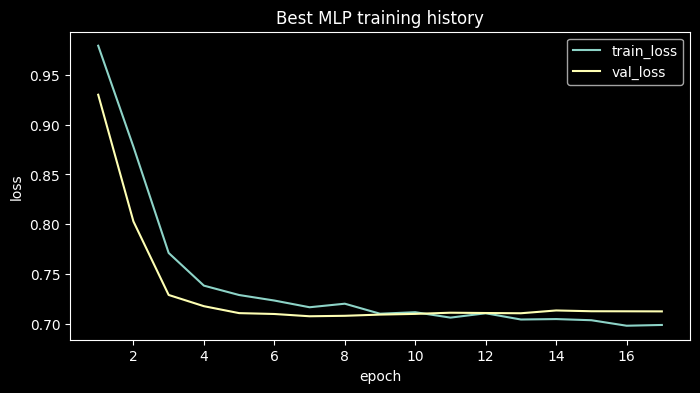

In [44]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(best_history_df["epoch"], best_history_df["train_loss"], label="train_loss")
ax.plot(best_history_df["epoch"], best_history_df["val_loss"], label="val_loss")
ax.set_title("Best MLP training history")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.legend()
plt.show()


In [45]:
best_hidden_dims = eval(best_config["hidden_dims"])
best_dropout_rates = eval(best_config["dropout_rates"])
mlp = ChurnMLP(X_train_dense.shape[1], best_hidden_dims, best_dropout_rates).to(device)
mlp.load_state_dict(best_model_state)

trainable_parameter_count = sum(parameter.numel() for parameter in mlp.parameters() if parameter.requires_grad)
total_parameter_count = sum(parameter.numel() for parameter in mlp.parameters())

pd.Series({
    "input_dim": int(X_train_dense.shape[1]),
    "trainable_parameters": int(trainable_parameter_count),
    "total_parameters": int(total_parameter_count),
    "positive_class_weight": round(positive_weight, 4),
    "epochs_ran": int(best_history_df["epoch"].max()),
    "best_hidden_dims": str(best_hidden_dims),
    "best_dropout_rates": str(best_dropout_rates),
    "best_learning_rate": best_config["learning_rate"],
    "best_weight_decay": best_config["weight_decay"],
    "best_batch_size": best_config["batch_size"],
    "source_candidate_run_id": best_config["run_id"],
})


input_dim                                                49
trainable_parameters                                  14721
total_parameters                                      14721
positive_class_weight                                2.7684
epochs_ran                                               17
best_hidden_dims                                  (128, 64)
best_dropout_rates                               (0.2, 0.1)
best_learning_rate                                   0.0005
best_weight_decay                                    0.0001
best_batch_size                                         256
source_candidate_run_id    0ad49ae092594e74bd7296d57e54f609
dtype: object

In [46]:
mlp_val_proba = predict_mlp_proba(mlp, X_val_tensor)
mlp_test_proba = predict_mlp_proba(mlp, X_test_tensor)
mlp_threshold, mlp_threshold_df = find_best_threshold(y_val, mlp_val_proba)

mlp_val_metrics = score_binary_classifier("mlp_pytorch_tuned_validation", y_val, mlp_val_proba, mlp_threshold)
mlp_metrics = score_binary_classifier("mlp_pytorch_tuned", y_test, mlp_test_proba, mlp_threshold)

with mlflow.start_run(run_name="dl_benchmark_mlp_best_test") as run:
    log_benchmark_context(
        run_purpose="mlp_best_test",
        model_family="pytorch_mlp",
        extra_tags={"source_candidate_run_id": best_config["run_id"]},
        extra_params={
            "hidden_dims": best_hidden_dims,
            "dropout_rates": best_dropout_rates,
            "learning_rate": best_config["learning_rate"],
            "weight_decay": best_config["weight_decay"],
            "batch_size": best_config["batch_size"],
            "threshold_strategy": "validation_f1",
        },
    )
    mlflow.log_metrics(float_metrics_with_prefix(mlp_val_metrics, "val_"))
    mlflow.log_metrics(float_metrics_with_prefix(mlp_metrics, "test_"))
    mlflow.log_metrics({
        "epochs_ran": float(best_history_df["epoch"].max()),
        "trainable_parameters": float(trainable_parameter_count),
        "total_parameters": float(total_parameter_count),
        "positive_class_weight": float(positive_weight),
    })
    mlflow.log_dict(best_history_df.to_dict(orient="records"), "tables/mlp_best_history.json")
    mlflow.log_dict(best_config, "tables/mlp_best_config.json")
    mlflow.log_dict(mlp_threshold_df.to_dict(orient="records"), "tables/mlp_best_threshold_table.json")

    history_fig, history_ax = plt.subplots(figsize=(8, 4))
    history_ax.plot(best_history_df["epoch"], best_history_df["train_loss"], label="train_loss")
    history_ax.plot(best_history_df["epoch"], best_history_df["val_loss"], label="val_loss")
    history_ax.set_title("Best MLP training history")
    history_ax.set_xlabel("epoch")
    history_ax.set_ylabel("loss")
    history_ax.legend()
    mlflow.log_figure(history_fig, "figures/mlp_best_history.png")
    plt.close(history_fig)

    mlp_input_example = X_train_dense[:5]
    mlp_signature = infer_signature(mlp_input_example, predict_mlp_proba(mlp, torch.tensor(mlp_input_example, device=device)))
    logged_mlp = copy.deepcopy(mlp).to("cpu")
    logged_mlp.eval()
    mlflow.pytorch.log_model(logged_mlp, name="model", input_example=mlp_input_example, signature=mlp_signature)
    best_mlp_run_id = run.info.run_id

mlp_metrics["run_id"] = best_mlp_run_id
pd.Series(mlp_metrics)


2026/03/22 20:59:48 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/22 20:59:48 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/03/22 20:59:58 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to mak

model                       mlp_pytorch_tuned
threshold                                 0.7
accuracy                               0.7956
precision                            0.615591
recall                               0.612299
f1                                   0.613941
roc_auc                              0.841179
run_id       97df2aa6556541d3a491de675ad24fee
dtype: object

## Comparacao final

O objetivo aqui nao e substituir automaticamente o XGBoost, e sim verificar se o projeto tambem cobre uma abordagem de deep learning como diferencial tecnico.


In [47]:
comparison_df = pd.DataFrame([xgb_metrics, mlp_metrics]).sort_values("roc_auc", ascending=False).reset_index(drop=True)
comparison_df


,model,threshold,accuracy,precision,recall,f1,roc_auc,run_id
0,xgboost_with_tenure_group,0.6,0.772179,0.555556,0.708556,0.622797,0.844036,5ce742d2dc144debba914dddfa7c3cca
1,mlp_pytorch_tuned,0.7,0.795600,0.615591,0.612299,0.613941,0.841179,97df2aa6556541d3a491de675ad24fee


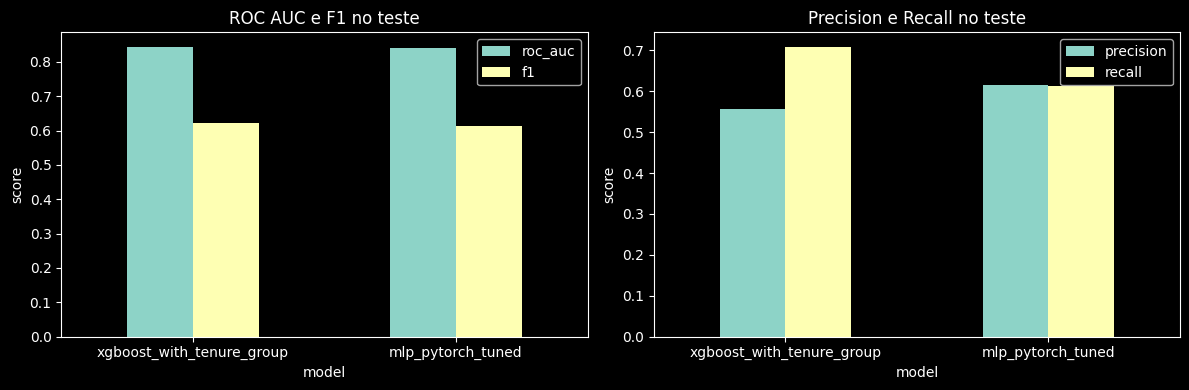

'5f67f3bfcc014efdad21bb2176d6523a'

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
comparison_df.plot(x="model", y=["roc_auc", "f1"], kind="bar", ax=axes[0], rot=0)
axes[0].set_title("ROC AUC e F1 no teste")
axes[0].set_ylabel("score")

comparison_df.plot(x="model", y=["precision", "recall"], kind="bar", ax=axes[1], rot=0)
axes[1].set_title("Precision e Recall no teste")
axes[1].set_ylabel("score")

with mlflow.start_run(run_name="dl_benchmark_summary") as run:
    log_benchmark_context(
        run_purpose="benchmark_summary",
        model_family="benchmark_summary",
        extra_tags={"xgboost_run_id": xgb_run_id, "best_mlp_run_id": best_mlp_run_id},
    )
    mlflow.log_dict(search_results_df.to_dict(orient="records"), "tables/mlp_search_results.json")
    mlflow.log_dict(comparison_df.to_dict(orient="records"), "tables/final_comparison.json")
    summary_metrics = {}
    for row in comparison_df.to_dict(orient="records"):
        model_key = str(row["model"]).replace("-", "_")
        summary_metrics[f"{model_key}_test_roc_auc"] = float(row["roc_auc"])
        summary_metrics[f"{model_key}_test_f1"] = float(row["f1"])
    mlflow.log_metrics(summary_metrics)
    mlflow.log_figure(fig, "figures/final_comparison.png")
    summary_run_id = run.info.run_id

plt.tight_layout()
plt.show()
summary_run_id
